In [40]:
import numpy as np 
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [41]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [42]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x=df['feature1'],
    y=df['feature2'],
    z=df['feature3'],
    color=df['target'].astype(str)
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(
            width=2,
            color='DarkSlateGrey'
        )
    ),
    selector=dict(mode='markers')
)

fig.show()

In [43]:
# Step-1: Applying the standard scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:, 0:3] = scaler.fit_transform(df.iloc[:, 0:3])

In [44]:
# Step-2: Find the Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]])
covariance_matrix

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [45]:
# Step-3: Finding Eigen vector and value    
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [46]:
eigen_values

array([1.3536065 +0.j, 0.94557084+0.j, 0.77774573+0.j])

In [47]:
eigen_vectors

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j],
       [-0.52848211+0.j,  0.72025103+0.j,  0.44938304+0.j]])

/Users/apple/Desktop/AI-ML/machine_learning/venv/lib/python3.14/site-packages/matplotlib/transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


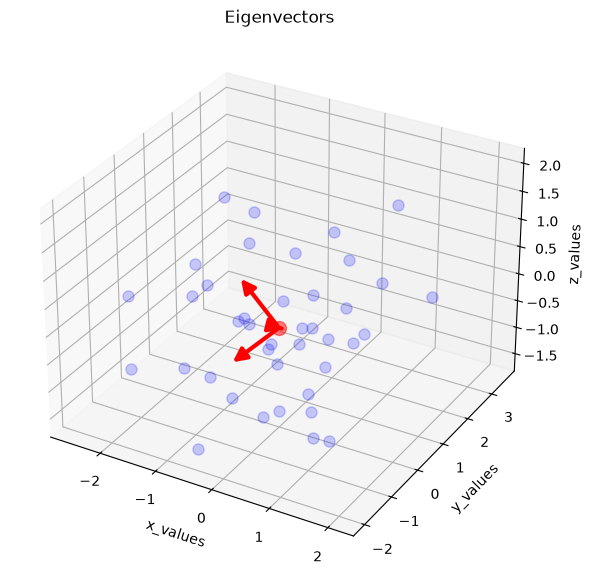

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(
            self,
            (0, 0),
            (0, 0),
            *args,
            **kwargs
        )

        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.M
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        FancyArrowPatch.draw(self, renderer)

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.M
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        return min(zs)


fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(111, projection='3d')


# Plot data points
ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)


# Plot mean point
ax.plot(
    [df['feature1'].mean()],
    [df['feature2'].mean()],
    [df['feature3'].mean()],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)


# Plot eigenvectors
for v in eigen_vectors.T:

    a = Arrow3D(
        [df['feature1'].mean(), df['feature1'].mean() + v[0]],
        [df['feature2'].mean(), df['feature2'].mean() + v[1]],
        [df['feature3'].mean(), df['feature3'].mean() + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="red"
    )

    ax.add_artist(a)


ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [49]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j]])

In [50]:
transformed_df = np.dot(df.iloc[:, 0:3], pc.T)

new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
new_df['target'] =  df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433+0.000000j,1.795862+0.000000j,1
1,1.056919+0.000000j,-0.212737+0.000000j,0
2,-0.271876+0.000000j,0.498222+0.000000j,1
3,-0.621586+0.000000j,0.023110+0.000000j,1
4,1.567286+0.000000j,1.730967+0.000000j,1


In [58]:
import numpy as np
import plotly.express as px

# 1. Convert complex numbers to real values using numpy
new_df['PC1'] = np.real(new_df['PC1'])
new_df['PC2'] = np.real(new_df['PC2'])

# 2. Use 2D scatter plot (use px.scatter_3d only if you pass a 'z' column)
fig = px.scatter(
    new_df,
    x='PC1',
    y='PC2',
    color=new_df['target'].astype(str),
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=2, color='DarkSlateGrey')
    ),
    selector=dict(mode='markers')
)

fig.show()
